In [ ]:
from google.colab import drive

In [ ]:
import pandas as pd
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Mašinsko učenje/clean_dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


In [ ]:
df.head()

,Attrition_Flag_clean,Customer_Age_clean,Gender_clean,Dependent_count_clean,Education_Level_clean,Marital_Status_clean,Income_Category_clean,Card_Category_clean,Months_on_book_clean,Total_Relationship_Count_clean,Months_Inactive_clean,Contacts_Count_clean,Credit_Limit_clean,Total_Revolving_Bal_clean,Avg_Open_To_Buy_clean,Total_Amt_Chng_clean,Total_Trans_Amt_clean,Total_Trans_Ct_clean,Total_Ct_Chng_clean,Avg_Utilization_Ratio_clean
0,Existing Customer,45.0,M,3.0,High School,Married,$60K - $80K,Blue,39.0,4.0,1.0,3.0,4537.0,777.0,3473.0,0.737,1144.0,42.0,1.625,0.061
1,Existing Customer,49.0,F,5.0,Graduate,Single,Less than $40K,Blue,44.0,6.0,1.0,2.0,8256.0,1249.0,3473.0,0.737,1291.0,67.0,3.714,0.105
2,Existing Customer,46.0,M,3.0,Graduate,Married,$80K - $120K,Blue,36.0,4.0,1.0,2.0,3418.0,0.0,3418.0,2.594,1887.0,20.0,2.333,0.000
3,Existing Customer,46.0,F,4.0,High School,Unknown,Less than $40K,Blue,34.0,3.0,4.0,2.0,3313.0,1249.0,796.0,1.405,1171.0,20.0,2.333,0.760
4,Existing Customer,46.0,M,3.0,Uneducated,Married,$60K - $80K,Blue,36.0,5.0,2.0,2.0,4716.0,0.0,4716.0,2.175,3899.0,28.0,2.500,0.000


In [ ]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Attrition_Flag_clean            10127 non-null  object 
 1   Customer_Age_clean              10127 non-null  float64
 2   Gender_clean                    10127 non-null  object 
 3   Dependent_count_clean           10127 non-null  float64
 4   Education_Level_clean           10127 non-null  object 
 5   Marital_Status_clean            10127 non-null  object 
 6   Income_Category_clean           10127 non-null  object 
 7   Card_Category_clean             10127 non-null  object 
 8   Months_on_book_clean            10127 non-null  float64
 9   Total_Relationship_Count_clean  10127 non-null  float64
 10  Months_Inactive_clean           10127 non-null  float64
 11  Contacts_Count_clean            10127 non-null  float64
 12  Credit_Limit_clean              

,0
Attrition_Flag_clean,0
Customer_Age_clean,0
Gender_clean,0
Dependent_count_clean,0
Education_Level_clean,0
Marital_Status_clean,0
Income_Category_clean,0
Card_Category_clean,0
Months_on_book_clean,0
Total_Relationship_Count_clean,0


In [ ]:
X = df.drop(columns=['Attrition_Flag_clean'])

In [ ]:
X_encoded = pd.get_dummies(X)

In [ ]:
X_encoded.shape
X_encoded.dtypes.value_counts()

,count
bool,24
float64,14


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

X_scaled.shape

(10127, 38)

In [ ]:
from sklearn.decomposition import PCA

pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_2.explained_variance_ratio_, pca_2.explained_variance_ratio_.sum()

(array([0.10231183, 0.06136341]), np.float64(0.16367524271084982))

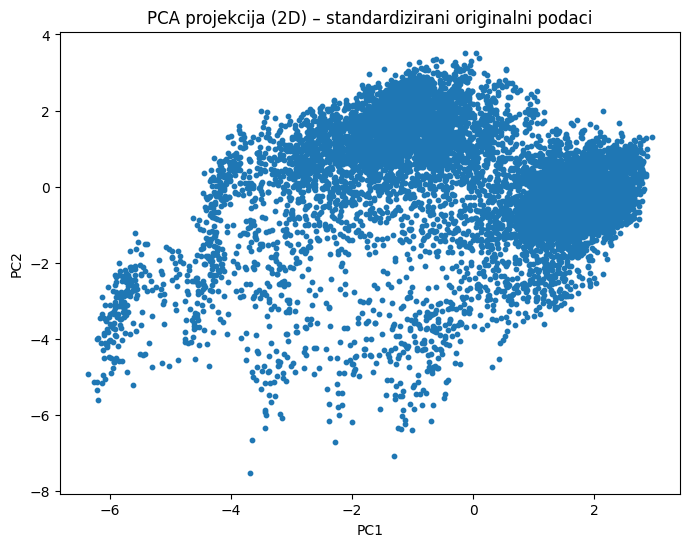

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projekcija (2D) – standardizirani originalni podaci")
plt.show()


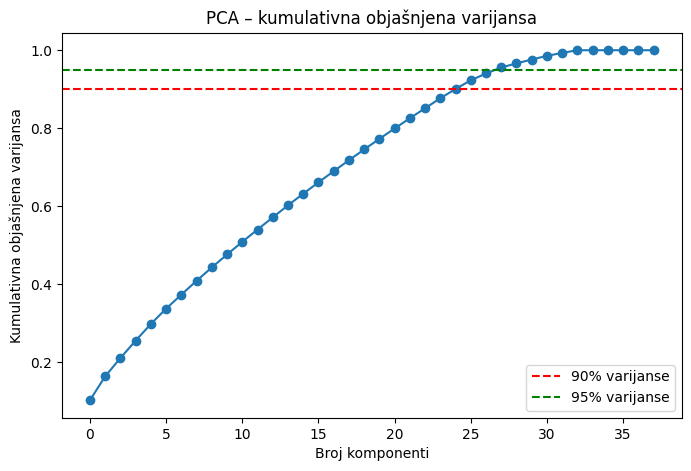

In [ ]:
pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(cum_var, marker='o')
plt.axhline(0.9, color='red', linestyle='--', label='90% varijanse')
plt.axhline(0.95, color='green', linestyle='--', label='95% varijanse')
plt.xlabel("Broj komponenti")
plt.ylabel("Kumulativna objašnjena varijansa")
plt.title("PCA – kumulativna objašnjena varijansa")
plt.legend()
plt.show()

In [ ]:
n_components = 23
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("X_pca shape:", X_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_.sum())


X_pca shape: (10127, 23)
Explained variance: 0.8512376250676591


In [ ]:
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt

K_range = range(2, 11)
bic_scores, aic_scores = [], []

for k in K_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=10,
        reg_covar=1e-6
    )
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))
    aic_scores.append(gmm.aic(X_pca))

best_k = list(K_range)[int(np.argmin(bic_scores))]
print("Najbolji K po BIC:", best_k)


Najbolji K po BIC: 10


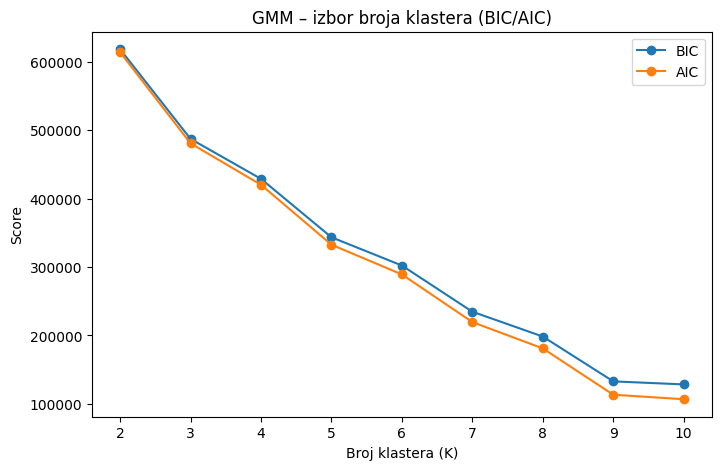

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(list(K_range), bic_scores, marker='o', label='BIC')
plt.plot(list(K_range), aic_scores, marker='o', label='AIC')
plt.xlabel("Broj klastera (K)")
plt.ylabel("Score")
plt.title("GMM – izbor broja klastera (BIC/AIC)")
plt.legend()
plt.show()


In [ ]:
cov_types = ["full", "tied", "diag", "spherical"]


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

cov_types = ["full", "tied", "diag", "spherical"]
rows = []

for cov in cov_types:
    gmm = GaussianMixture(
        n_components=10,          # K po BIC
        covariance_type=cov,
        random_state=42,
        n_init=10,
        reg_covar=1e-6
    )
    labels = gmm.fit_predict(X_pca)

    sil = silhouette_score(X_pca, labels)
    db  = davies_bouldin_score(X_pca, labels)
    ch  = calinski_harabasz_score(X_pca, labels)

    rows.append((cov, sil, db, ch))

results_cov = pd.DataFrame(
    rows,
    columns=["covariance_type", "silhouette", "davies_bouldin", "calinski_harabasz"]
)

results_cov


,covariance_type,silhouette,davies_bouldin,calinski_harabasz
0,full,0.111103,2.162553,572.275878
1,tied,0.090015,2.169962,556.964724
2,diag,0.042176,2.586792,391.034746
3,spherical,0.054868,2.257724,516.476095


In [ ]:
results_cov.sort_values("silhouette", ascending=False)


,covariance_type,silhouette,davies_bouldin,calinski_harabasz
0,full,0.111103,2.162553,572.275878
1,tied,0.090015,2.169962,556.964724
3,spherical,0.054868,2.257724,516.476095
2,diag,0.042176,2.586792,391.034746


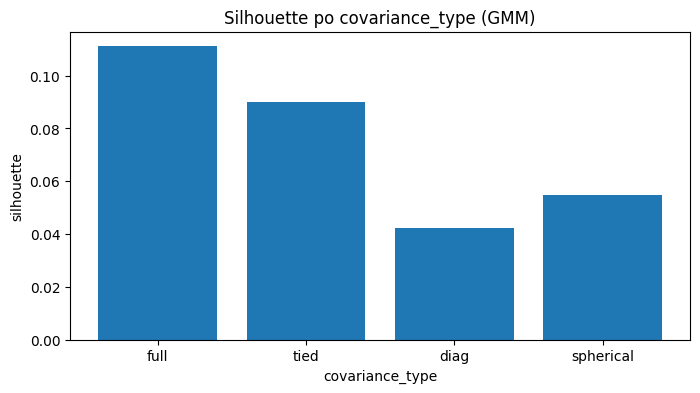

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(results_cov["covariance_type"], results_cov["silhouette"])
plt.title("Silhouette po covariance_type (GMM)")
plt.xlabel("covariance_type")
plt.ylabel("silhouette")
plt.show()


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

gmm_final = GaussianMixture(
    n_components=10,
    covariance_type="full",
    random_state=42,
    n_init=20,
    reg_covar=1e-6
)

gmm_labels = gmm_final.fit_predict(X_pca)

sil = silhouette_score(X_pca, gmm_labels)
db  = davies_bouldin_score(X_pca, gmm_labels)
ch  = calinski_harabasz_score(X_pca, gmm_labels)

print("FINAL GMM")
print("Silhouette:", round(sil,4))
print("Davies–Bouldin:", round(db,4))
print("Calinski–Harabasz:", round(ch,2))


FINAL GMM
Silhouette: 0.1099
Davies–Bouldin: 2.2753
Calinski–Harabasz: 557.77


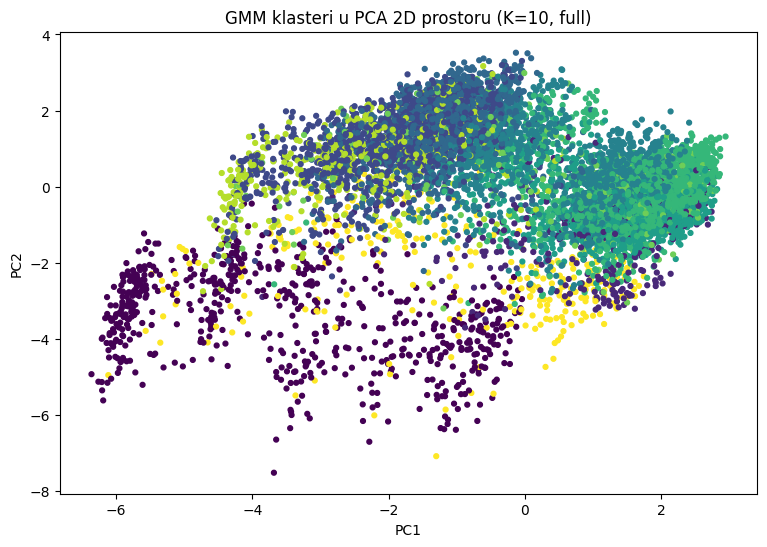

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=gmm_labels, s=12)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM klasteri u PCA 2D prostoru (K=10, full)")
plt.show()


In [ ]:
df["GMM_Cluster"] = gmm_labels
df["GMM_Cluster"].value_counts().sort_index()


,count
GMM_Cluster,
0,651
1,497
2,1275
3,1149
4,1517
5,1854
6,1892
7,394
8,576


In [ ]:
profile_cols = [
    "Credit_Limit_clean",
    "Total_Trans_Amt_clean",
    "Total_Trans_Ct_clean",
    "Customer_Age_clean"
]

df.groupby("GMM_Cluster")[profile_cols].mean().round(2)


,Credit_Limit_clean,Total_Trans_Amt_clean,Total_Trans_Ct_clean,Customer_Age_clean
GMM_Cluster,,,,
0,21013.74,6097.56,73.64,45.75
1,6188.52,6073.89,72.15,44.81
2,11898.57,4229.74,62.72,46.31
3,7586.00,4117.21,63.10,46.04
4,4616.40,4198.45,65.00,46.01
5,4225.42,3831.05,66.41,46.12
6,4352.99,3953.06,63.71,46.54
7,6725.73,4042.11,64.34,47.42
8,14906.55,4194.28,63.09,47.24


In [ ]:
df.groupby("GMM_Cluster")["Education_Level_clean"] \
  .agg(lambda x: x.mode().iloc[0])


,Education_Level_clean
GMM_Cluster,
0,Graduate
1,Graduate
2,Graduate
3,Graduate
4,Graduate
5,Graduate
6,Graduate
7,Doctorate
8,Graduate


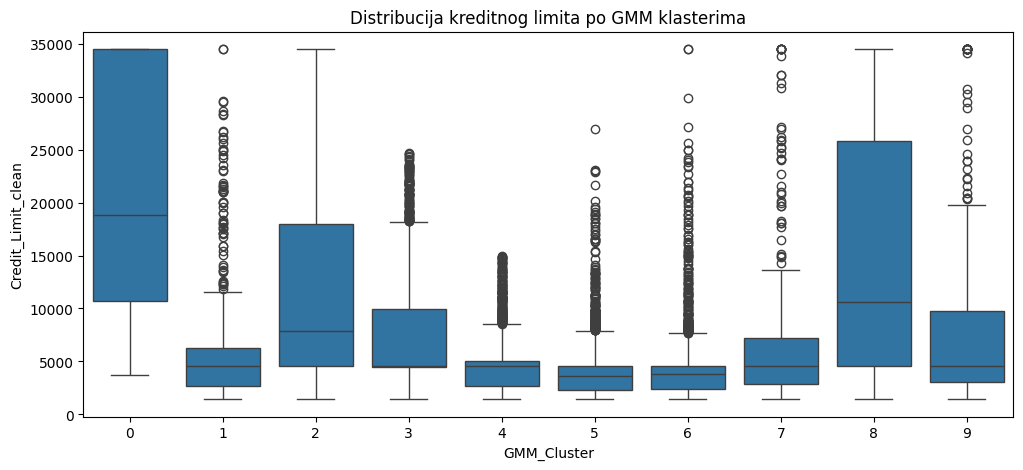

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
sns.boxplot(x="GMM_Cluster", y="Credit_Limit_clean", data=df)
plt.title("Distribucija kreditnog limita po GMM klasterima")
plt.show()


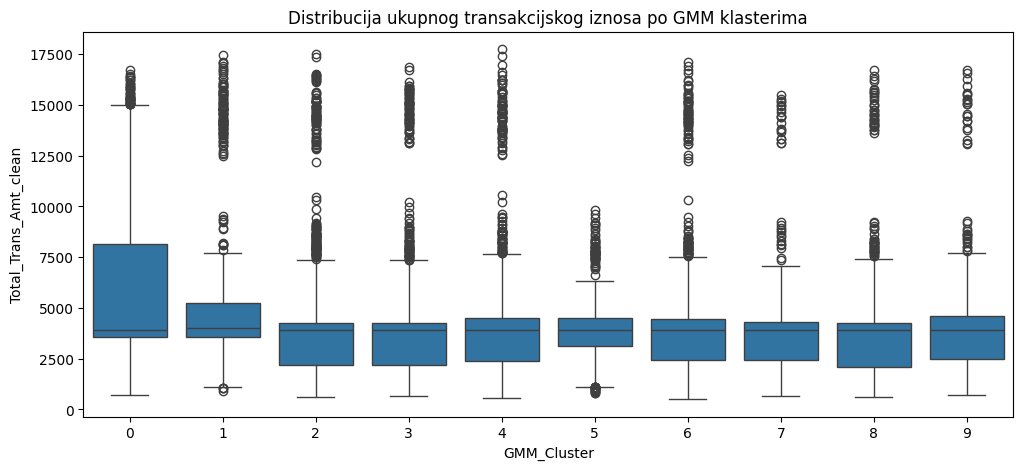

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(x="GMM_Cluster", y="Total_Trans_Amt_clean", data=df)
plt.title("Distribucija ukupnog transakcijskog iznosa po GMM klasterima")
plt.show()


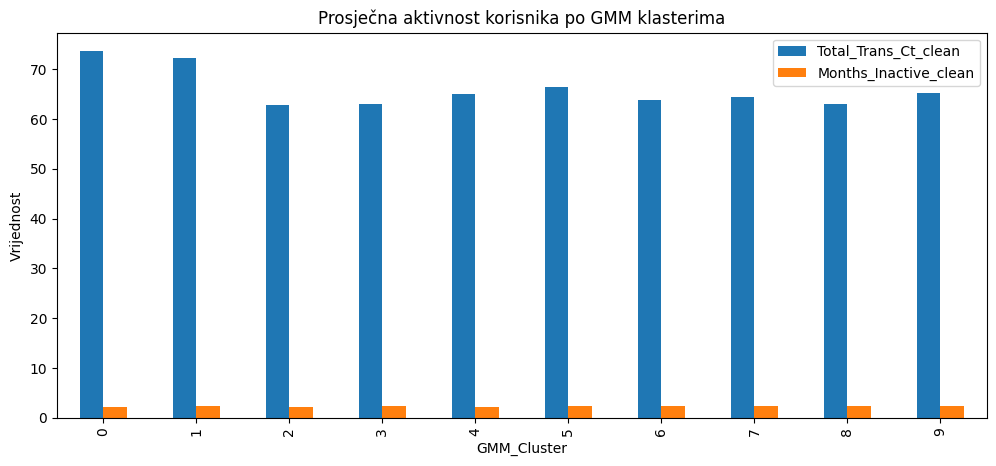

In [ ]:
activity_means = df.groupby("GMM_Cluster")[
    ["Total_Trans_Ct_clean", "Months_Inactive_clean"]
].mean()

activity_means.plot(kind="bar", figsize=(12,5))
plt.title("Prosječna aktivnost korisnika po GMM klasterima")
plt.ylabel("Vrijednost")
plt.show()


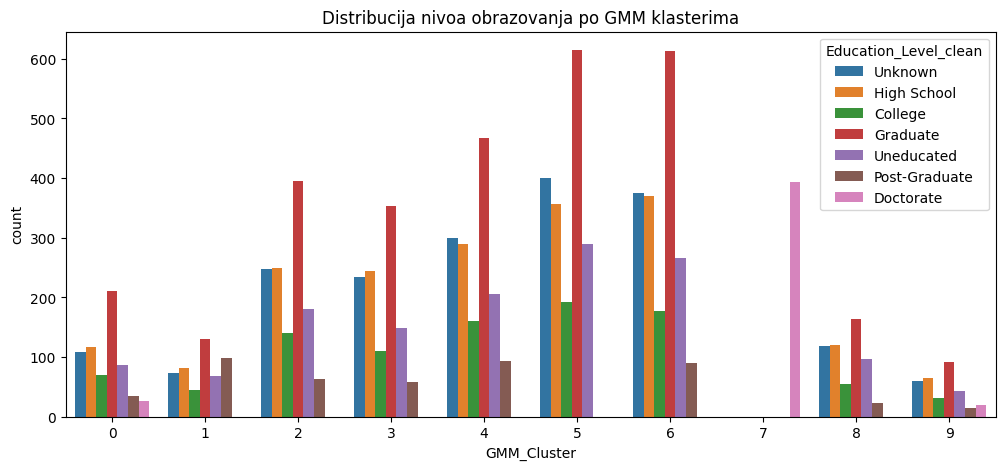

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(x="GMM_Cluster", hue="Education_Level_clean", data=df)
plt.title("Distribucija nivoa obrazovanja po GMM klasterima")
plt.xticks(rotation=0)
plt.show()


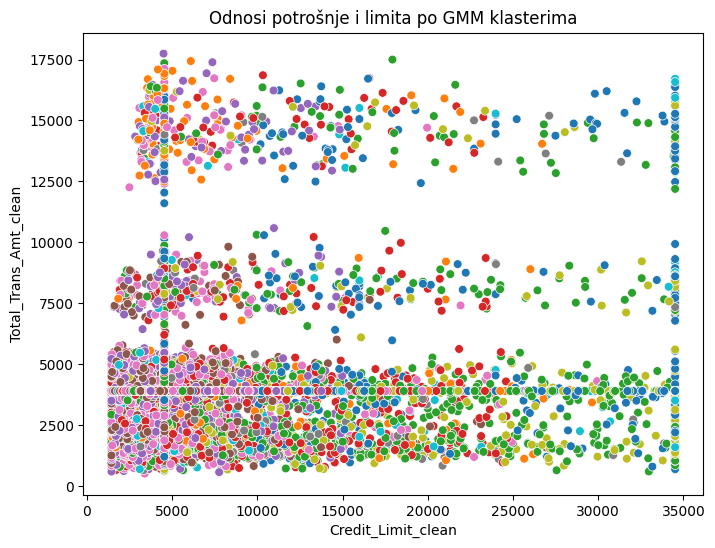

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Credit_Limit_clean",
    y="Total_Trans_Amt_clean",
    hue="GMM_Cluster",
    data=df,
    palette="tab10",
    s=40,
    legend=False
)
plt.title("Odnosi potrošnje i limita po GMM klasterima")
plt.show()


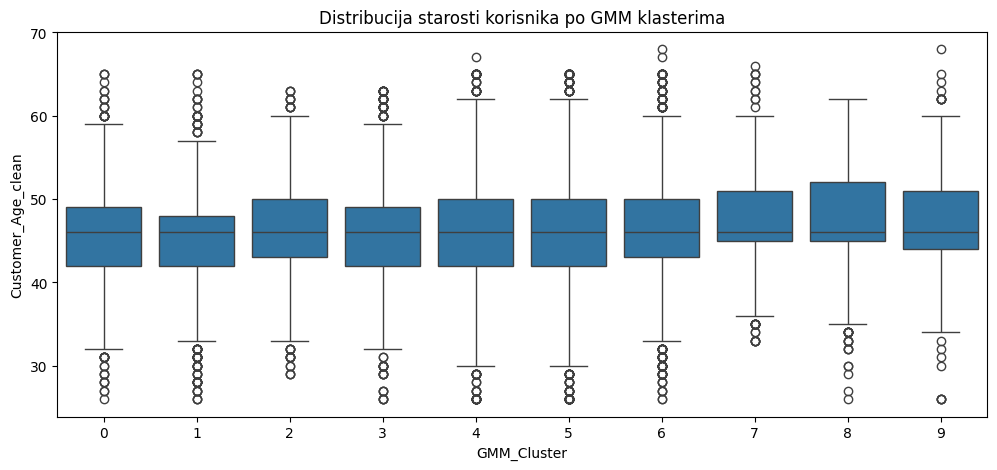

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(x="GMM_Cluster", y="Customer_Age_clean", data=df)
plt.title("Distribucija starosti korisnika po GMM klasterima")
plt.show()
